# Markov-chain diagnostics & models — IG window-level RCEDTG panel

**Plots only.** All heavy computation is done by the Python scripts in this folder; this notebook just reads their CSV outputs from `outputs/` and renders figures.

| script | what it computes |
|---|---|
| `markov_stationarity_tests.py` | order tests, Anderson-Goodman homogeneity, pooled P, asymptotics, marginal drift, partial stationarity |
| `markov_mature_refit.py` | recurrent 5-state chain refit on the mature window (2024-09+), full-vs-mature comparison, per-step TV, reactivation hazard |
| `markov_absorbing_churn.py` | duration-based absorbing-churn chain (full + mature): P, fundamental matrix, survival curves |

Run the scripts first (they write `outputs/`), then run this notebook.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

OUT = 'outputs'
mpl.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.25})
ACTIVE = ['C1', 'C2', 'C3', 'C4', 'Inactive']
STATES6 = ['C1', 'C2', 'C3', 'C4', 'Inactive', 'Churned']
CNAME = {'C1': 'C1 Brand advocates', 'C2': 'C2 Expressive reg.',
         'C3': 'C3 Passive reg.', 'C4': 'C4 Delayed visitors',
         'Inactive': 'Inactive', 'Churned': 'Churned'}

def savefig(fig, name):
    p = os.path.join(OUT, name)
    fig.savefig(p, bbox_inches='tight')
    print('saved', p)

## 1. Transition matrices — heatmaps
Recurrent 5-state chain (full span) vs the absorbing-churn 6-state chain.

saved outputs\fig1_transition_heatmaps.png


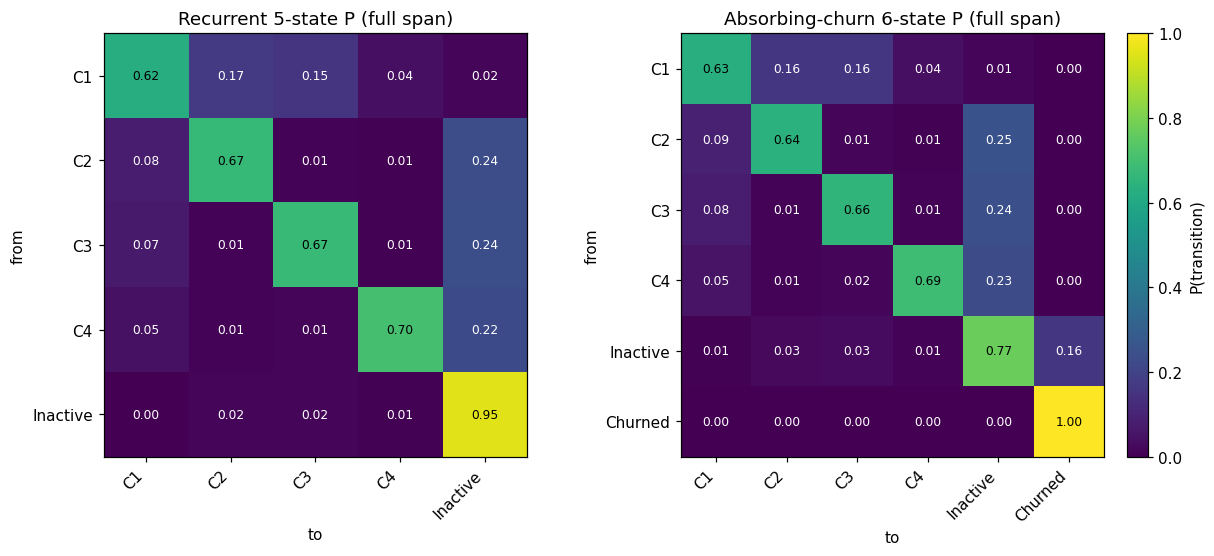

In [2]:
def heat(ax, P, states, title):
    im = ax.imshow(P.values, cmap='viridis', vmin=0, vmax=1)
    ax.set_xticks(range(len(states))); ax.set_yticks(range(len(states)))
    ax.set_xticklabels(states, rotation=45, ha='right'); ax.set_yticklabels(states)
    ax.set_xlabel('to'); ax.set_ylabel('from'); ax.set_title(title)
    ax.grid(False)
    for i in range(len(states)):
        for j in range(len(states)):
            v = P.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v < 0.55 else 'black', fontsize=8)
    return im

Pf = pd.read_csv(os.path.join(OUT, 'markov_pooled_P.csv'), index_col=0)
Pa = pd.read_csv(os.path.join(OUT, 'markov_absorbing_P.csv'), index_col=0)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
heat(axes[0], Pf, ACTIVE, 'Recurrent 5-state P (full span)')
im = heat(axes[1], Pa, STATES6, 'Absorbing-churn 6-state P (full span)')
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label='P(transition)')
savefig(fig, 'fig1_transition_heatmaps.png')
plt.show()

## 2. Full vs mature transition matrices (recurrent)
Difference heatmap shows where the mechanism shifts between the full span and the stationary 2024-09+ window.

saved outputs\fig2_full_vs_mature_P.png


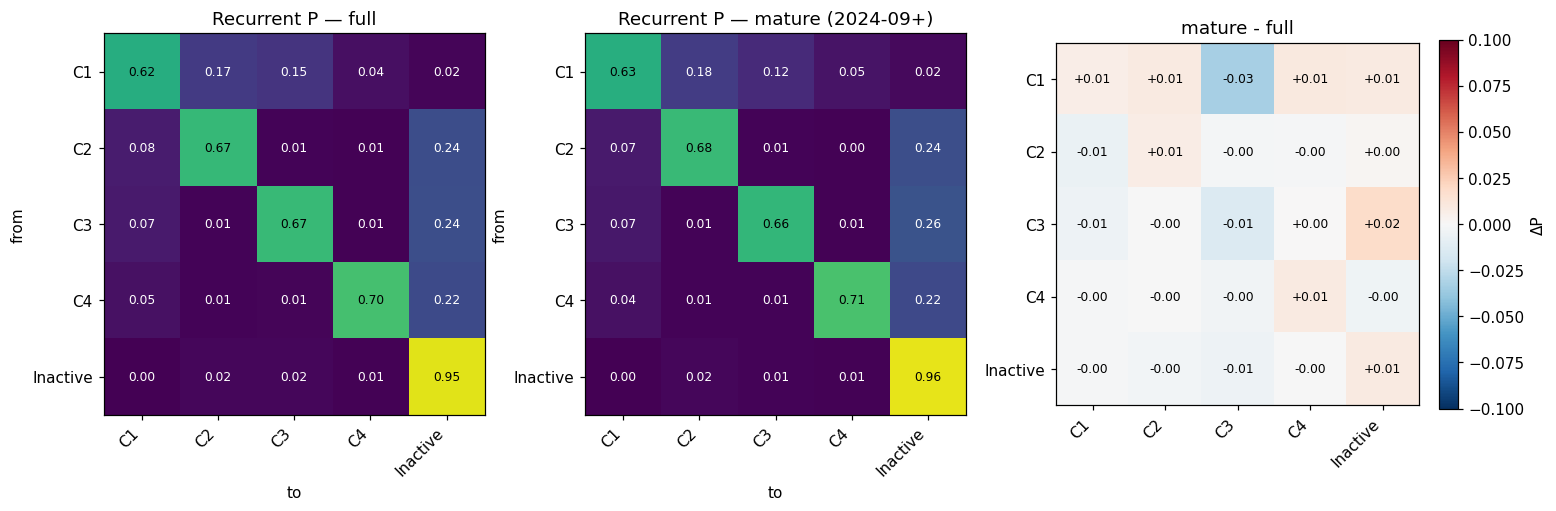

In [3]:
Pm = pd.read_csv(os.path.join(OUT, 'markov_pooled_P_mature.csv'), index_col=0)
diff = Pm - Pf
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
heat(axes[0], Pf, ACTIVE, 'Recurrent P — full')
heat(axes[1], Pm, ACTIVE, 'Recurrent P — mature (2024-09+)')
im = axes[2].imshow(diff.values, cmap='RdBu_r', vmin=-0.1, vmax=0.1)
axes[2].set_xticks(range(5)); axes[2].set_yticks(range(5))
axes[2].set_xticklabels(ACTIVE, rotation=45, ha='right'); axes[2].set_yticklabels(ACTIVE)
axes[2].set_title('mature - full'); axes[2].grid(False)
for i in range(5):
    for j in range(5):
        axes[2].text(j, i, f'{diff.values[i,j]:+.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=axes[2], fraction=0.046, label='ΔP')
savefig(fig, 'fig2_full_vs_mature_P.png')
plt.show()

## 3. Stationary distribution π (full vs mature)

saved outputs\fig3_stationary_pi.png


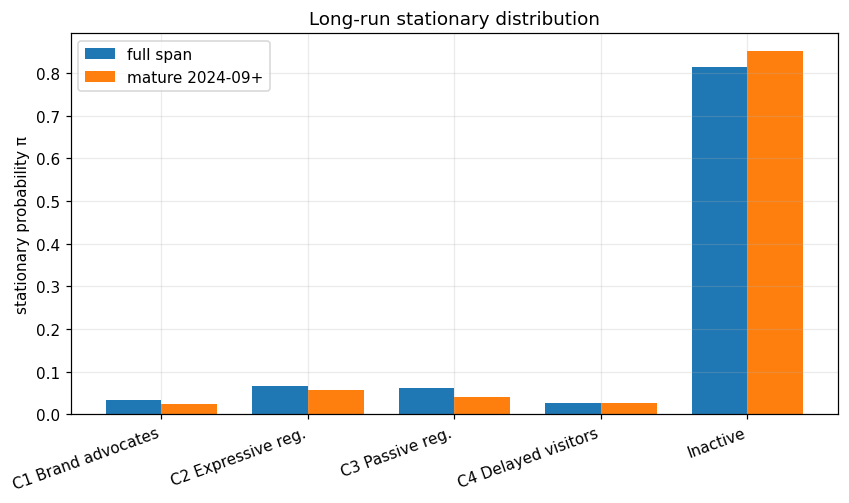

In [4]:
summ = pd.read_csv(os.path.join(OUT, 'markov_mature_summary.csv'))
pis = summ[summ.metric.str.startswith('pi_')].copy()
pis['state'] = pis.metric.str.replace('pi_', '', regex=False)
x = np.arange(len(ACTIVE)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, pis.set_index('state').loc[ACTIVE, 'full'], w, label='full span')
ax.bar(x + w/2, pis.set_index('state').loc[ACTIVE, 'mature'], w, label='mature 2024-09+')
ax.set_xticks(x); ax.set_xticklabels([CNAME[s] for s in ACTIVE], rotation=20, ha='right')
ax.set_ylabel('stationary probability π'); ax.set_title('Long-run stationary distribution')
ax.legend()
savefig(fig, 'fig3_stationary_pi.png')
plt.show()

## 4. Marginal state shares over time + convergence to π
Shows the cross-sectional drift (largely cohort maturation) and that recent windows sit near the stationary π.

saved outputs\fig4_marginal_drift_convergence.png


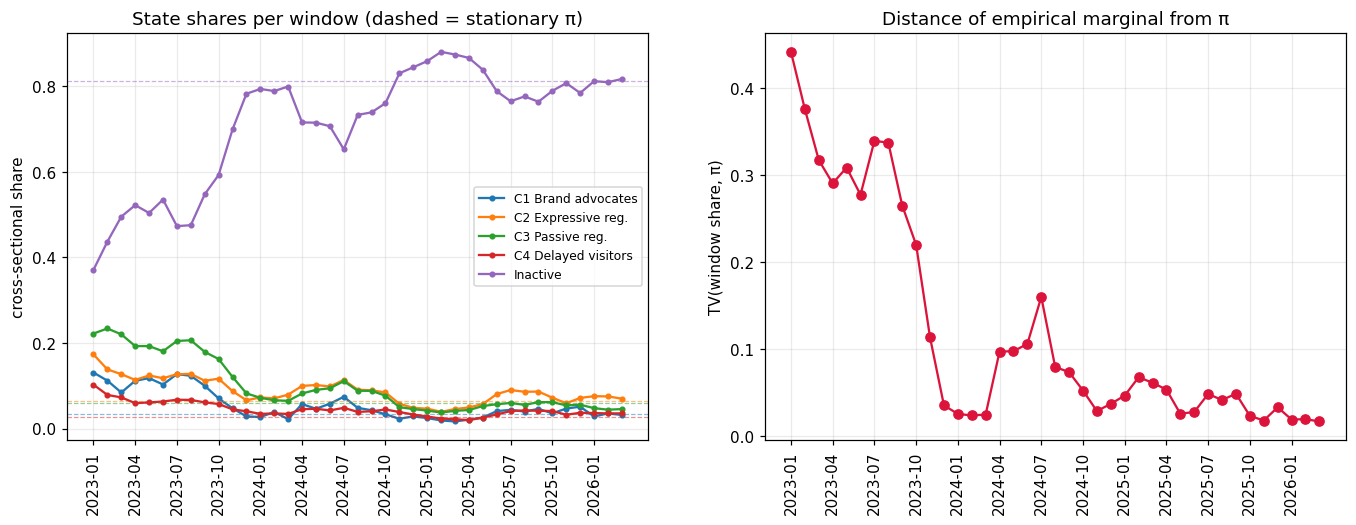

In [5]:
sh = pd.read_csv(os.path.join(OUT, 'markov_marginal_shares_by_window.csv'), index_col=0)
pi_full = pis.set_index('state').loc[ACTIVE, 'full']
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for s in ACTIVE:
    axes[0].plot(range(len(sh)), sh[s], marker='.', label=CNAME[s])
    axes[0].axhline(pi_full[s], ls='--', lw=0.8, alpha=0.5,
                    color=axes[0].lines[-1].get_color())
axes[0].set_xticks(range(0, len(sh), 3)); axes[0].set_xticklabels(sh.index[::3], rotation=90)
axes[0].set_ylabel('cross-sectional share'); axes[0].legend(fontsize=8)
axes[0].set_title('State shares per window (dashed = stationary π)')
# TV distance of each window vs pi
tv = 0.5 * (sh[ACTIVE] - pi_full).abs().sum(axis=1)
axes[1].plot(range(len(tv)), tv.values, marker='o', color='crimson')
axes[1].set_xticks(range(0, len(tv), 3)); axes[1].set_xticklabels(sh.index[::3], rotation=90)
axes[1].set_ylabel('TV(window share, π)'); axes[1].set_title('Distance of empirical marginal from π')
savefig(fig, 'fig4_marginal_drift_convergence.png')
plt.show()

## 5. Partial stationarity — per-step deviation of P_t from pooled P
Mass-weighted row TV distance per monthly step. The decline over time is the 'progressively settling' signal.

saved outputs\fig5_partial_stationarity_perstep.png


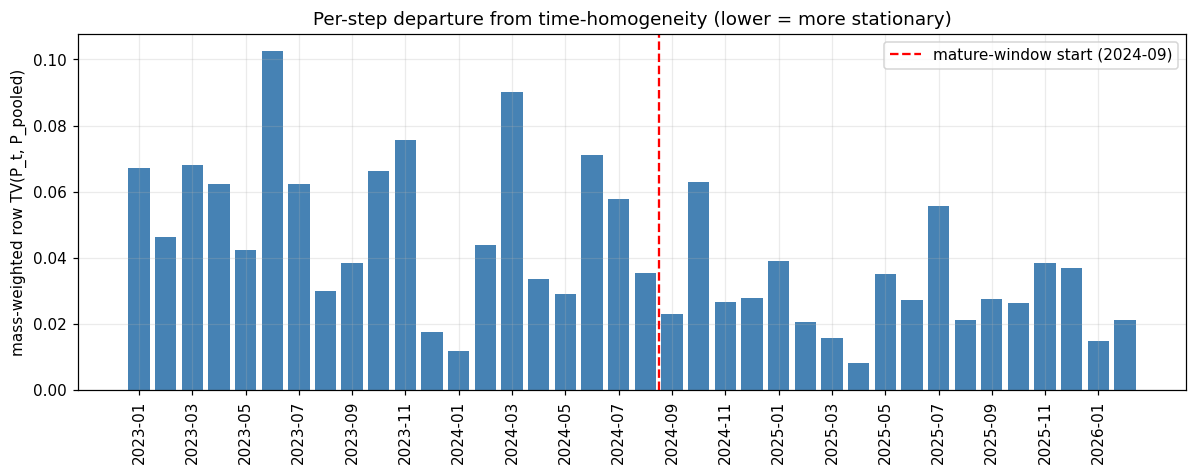

In [6]:
ps = pd.read_csv(os.path.join(OUT, 'markov_homogeneity_per_step.csv'))
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.bar(range(len(ps)), ps['rowTV_vs_pooled'], color='steelblue')
ax.axvline(list(ps['step_from']).index('2024-09') - 0.5, color='red', ls='--',
           label='mature-window start (2024-09)')
ax.set_xticks(range(0, len(ps), 2)); ax.set_xticklabels(ps['step_from'][::2], rotation=90)
ax.set_ylabel('mass-weighted row TV(P_t, P_pooled)')
ax.set_title('Per-step departure from time-homogeneity (lower = more stationary)')
ax.legend()
savefig(fig, 'fig5_partial_stationarity_perstep.png')
plt.show()

## 6. Reactivation hazard — why Inactive is not absorbing
Monthly probability of returning to an active state given still inactive at month j. Justifies the duration-based (≥6mo) churn definition.

saved outputs\fig6_reactivation_hazard.png


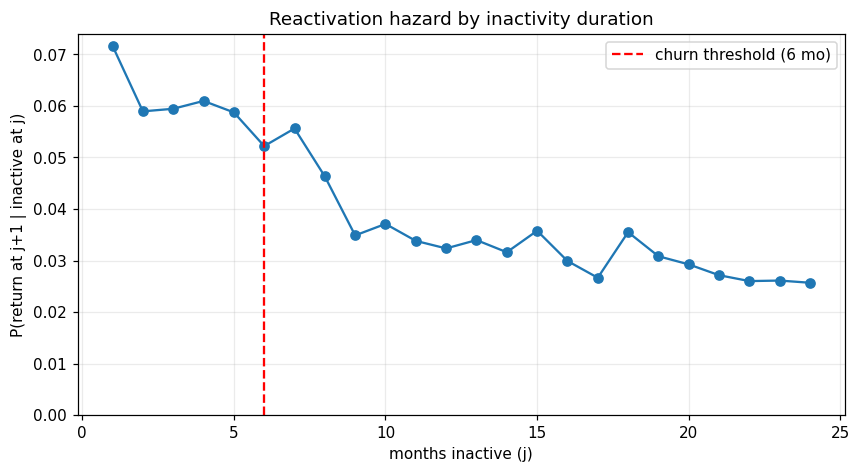

In [7]:
hz = pd.read_csv(os.path.join(OUT, 'markov_reactivation_hazard.csv'))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hz['inactive_month'], hz['return_hazard'], marker='o')
ax.axvline(6, color='red', ls='--', label='churn threshold (6 mo)')
ax.set_xlabel('months inactive (j)'); ax.set_ylabel('P(return at j+1 | inactive at j)')
ax.set_title('Reactivation hazard by inactivity duration')
ax.set_ylim(0, None); ax.legend()
savefig(fig, 'fig6_reactivation_hazard.png')
plt.show()

## 7. Survival curves — absorbing-churn model
P(not yet churned) over a 36-month horizon by starting state, full vs mature fit.

saved outputs\fig7_survival_curves.png


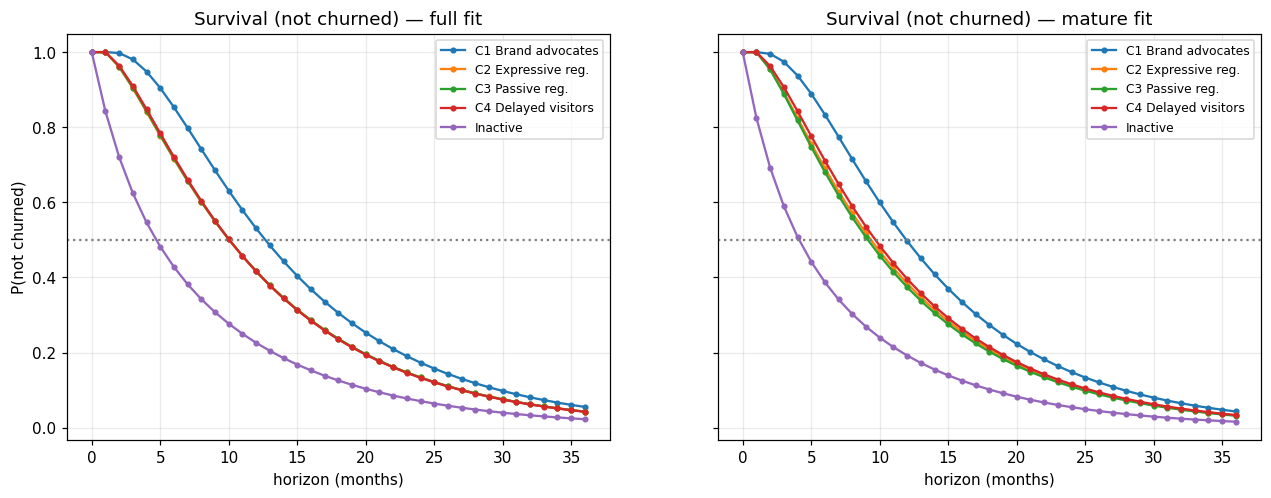

In [8]:
sv = pd.read_csv(os.path.join(OUT, 'markov_absorbing_survival.csv'), index_col=0)
svm = pd.read_csv(os.path.join(OUT, 'markov_absorbing_survival_mature.csv'), index_col=0)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for s in sv.columns:
    axes[0].plot(sv.index, sv[s], marker='.', label=CNAME[s])
    axes[1].plot(svm.index, svm[s], marker='.', label=CNAME[s])
axes[0].set_title('Survival (not churned) — full fit')
axes[1].set_title('Survival (not churned) — mature fit')
for a in axes:
    a.set_xlabel('horizon (months)'); a.axhline(0.5, ls=':', color='grey')
    a.legend(fontsize=8)
axes[0].set_ylabel('P(not churned)')
savefig(fig, 'fig7_survival_curves.png')
plt.show()

## 8. Expected time-to-churn by starting state

saved outputs\fig8_time_to_churn.png


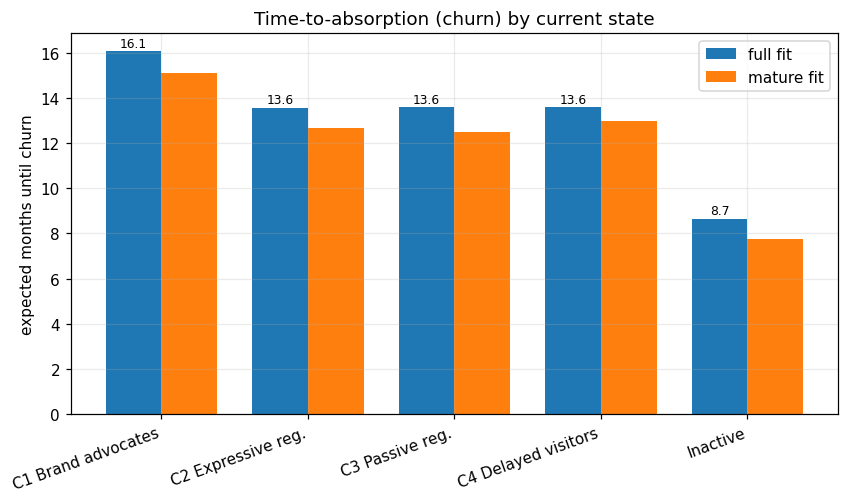

In [9]:
ff = pd.read_csv(os.path.join(OUT, 'markov_absorbing_fundamental.csv'), index_col=0)
fm = pd.read_csv(os.path.join(OUT, 'markov_absorbing_fundamental_mature.csv'), index_col=0)
states = ff.index.tolist()
x = np.arange(len(states)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, ff['expected_months_to_churn'], w, label='full fit')
ax.bar(x + w/2, fm['expected_months_to_churn'], w, label='mature fit')
ax.set_xticks(x); ax.set_xticklabels([CNAME[s] for s in states], rotation=20, ha='right')
ax.set_ylabel('expected months until churn'); ax.set_title('Time-to-absorption (churn) by current state')
for i, v in enumerate(ff['expected_months_to_churn']):
    ax.text(i - w/2, v + 0.2, f'{v:.1f}', ha='center', fontsize=8)
ax.legend()
savefig(fig, 'fig8_time_to_churn.png')
plt.show()